# C(Vgate, Vbias) map

This notebook loads all `.data` files in the specified folder and plots a 2D capacitance map.

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
data_dir = Path(r"D:\Iurii\2026-02-15\qc4_g2_bn1_keithlye_gate_no_G\data\CV_map_qc4_g2_bn1_keithlye_gate_no_G_2026-02-15_17-19-04")

files = sorted(data_dir.glob("*.data"))
if not files:
    raise FileNotFoundError(f"No .data files found in {data_dir}")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["_file"] = f.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Choose the best capacitance column available
cap_col_candidates = ["C_F", "param1", "param0"]
cap_col = next((c for c in cap_col_candidates if c in data.columns), None)
if cap_col is None:
    raise ValueError(f"No capacitance-like column found. Columns: {list(data.columns)}")

data = data.dropna(subset=["gate_V", "bias_V", cap_col])
data[["gate_V", "bias_V", cap_col]] = data[["gate_V", "bias_V", cap_col]].astype(float)

print(f"Loaded {len(files)} files, {len(data)} rows. Using capacitance column: {cap_col}")
print("Unique gate_V:", data["gate_V"].nunique(), "Unique bias_V:", data["bias_V"].nunique())


Loaded 121 files, 17061 rows. Using capacitance column: C_F
Unique gate_V: 121 Unique bias_V: 141


In [18]:
# Aggregate duplicates, then pivot to a 2D grid
grid = (
    data.groupby(["bias_V", "gate_V"], as_index=False)[cap_col]
    .mean()
    .pivot(index="bias_V", columns="gate_V", values=cap_col)
)

bias_vals = grid.index.to_numpy()
gate_vals = grid.columns.to_numpy()
C = grid.to_numpy()

print("Grid shape:", C.shape)
print("bias_V range:", bias_vals.min(), bias_vals.max())
print("gate_V range:", gate_vals.min(), gate_vals.max())


Grid shape: (141, 121)
bias_V range: -0.7 0.700000000000001
gate_V range: -60.0 60.0


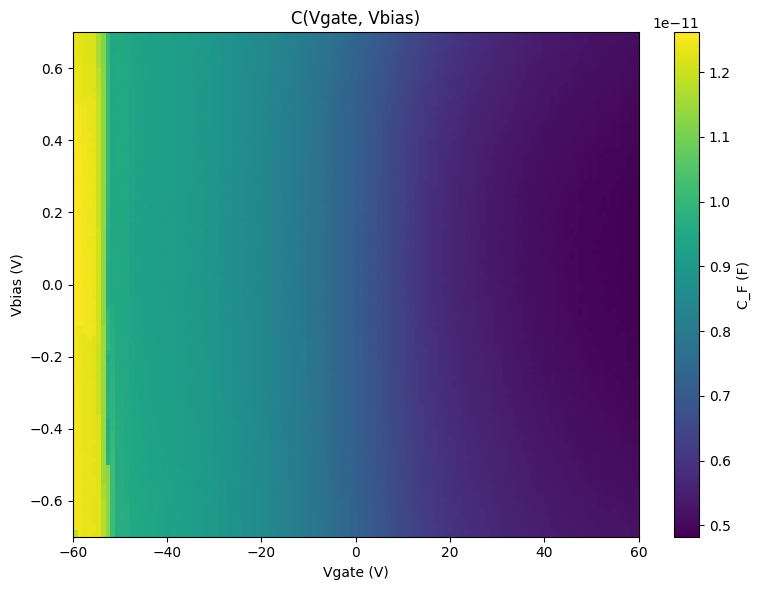

In [19]:
plt.figure(figsize=(8, 6))
extent = [gate_vals.min(), gate_vals.max(), bias_vals.min(), bias_vals.max()]

im = plt.imshow(
    C,
    origin="lower",
    aspect="auto",
    extent=extent,
)
plt.colorbar(im, label=f"{cap_col} (F)")
plt.xlabel("Vgate (V)")
plt.ylabel("Vbias (V)")
plt.title("C(Vgate, Vbias)")
plt.tight_layout()
plt.show()


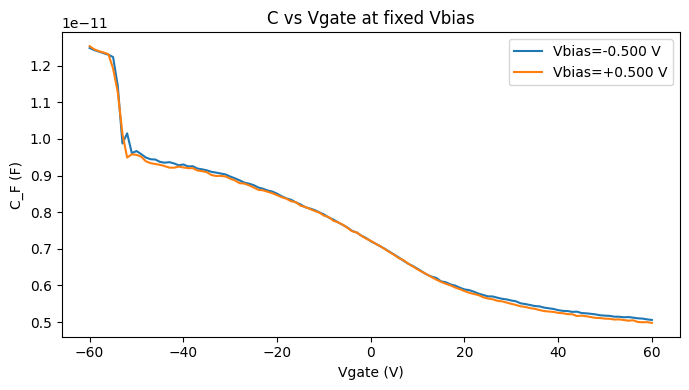

In [20]:
# Line cuts at fixed Vbias
targets = [-0.5, 0.5]

plt.figure(figsize=(7, 4))
for t in targets:
    idx = int(np.argmin(np.abs(bias_vals - t)))
    b = float(bias_vals[idx])
    if abs(b - t) > 1e-6:
        print(f"Note: Vbias target {t:+.3f} V not exact; using nearest {b:+.3f} V")
    plt.plot(gate_vals, C[idx, :], label=f"Vbias={b:+.3f} V")

plt.xlabel("Vgate (V)")
plt.ylabel(f"{cap_col} (F)")
plt.title("C vs Vgate at fixed Vbias")
plt.legend()
plt.tight_layout()
plt.show()


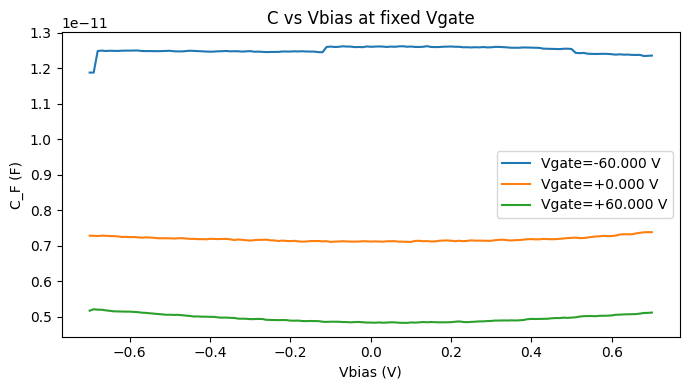

In [24]:
# Line cuts at fixed Vgate
targets = [float(gate_vals.min()), 0.0, float(gate_vals.max())]

plt.figure(figsize=(7, 4))
for t in targets:
    idx = int(np.argmin(np.abs(gate_vals - t)))
    g = float(gate_vals[idx])
    if abs(g - t) > 1e-6:
        print(f"Note: Vgate target {t:+.3f} V not exact; using nearest {g:+.3f} V")
    plt.plot(bias_vals, C[:, idx], label=f"Vgate={g:+.3f} V")

plt.xlabel("Vbias (V)")
plt.ylabel(f"{cap_col} (F)")
plt.title("C vs Vbias at fixed Vgate")
# plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()
